In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

# File paths (adjust if needed)
CAPTIONS_PATH = "RISCM/captions.csv"
IMAGES_DIR = "RISCM/resized/"

# Load captions.csv
df = pd.read_csv(CAPTIONS_PATH)
print(f"Total rows in captions.csv: {len(df)}")
df.head()


Total rows in captions.csv: 44521


,source,split,image,caption_1,caption_2,caption_3,caption_4,caption_5
0,NWPU,test,NWPU_31430.jpg,A gray plane on the runway and the lawn beside .,A grey plane is on the runway by the lawn .,There is an airplane on the runway with a larg...,A plane is parked on the runway next to the gr...,There is a plane on the runway beside the grass .
1,NWPU,test,NWPU_31431.jpg,Three small planes parked in a line on the air...,"There are four aircraft on the open ground, Th...",There are many planes of different sizes in a ...,Four planes are parked on the runway .,Four planes of different sizes were on the mar...
2,NWPU,test,NWPU_31432.jpg,A plane parked in a line on the airport with s...,A white plane was parked on the instruction li...,An airplane parked in an open area with many c...,A plane is parked on the open space .,There is 1 plane on the ground marked .
3,NWPU,test,NWPU_31433.jpg,A small plane and a big plane parked next to b...,A white plane and a gray plane parked at the b...,Two planes of different sizes are neatly parke...,A large plane and a small plane are parked nea...,Two planes are on the marked ground .
4,NWPU,test,NWPU_31434.jpg,Two planes parked next to boarding bridges .,Two aircraft were parked at the departure gates .,Two planes of different sizes are neatly parke...,Two planes are parked next to the terminal .,Two planes are on the marked ground .


check distributions of splits and caption counts

In [5]:
# Check split distribution
split_counts = df['split'].value_counts()
print("Split Distribution:\n", split_counts)

# Check number of captions per image
# Melt the wide-format caption columns into one long-format column
caption_cols = ['caption_1', 'caption_2', 'caption_3', 'caption_4', 'caption_5']
df_melted = df.melt(id_vars=['source', 'split', 'image'], value_vars=caption_cols, var_name='caption_id', value_name='caption')

# Now you can safely do the caption-level analysis
caption_counts = df_melted.groupby('image')['caption'].count().reset_index(name='count')
print("Caption count per image:\n", caption_counts['count'].value_counts())



Split Distribution:
 split
train    35614
test      4454
val       4453
Name: count, dtype: int64
Caption count per image:
 count
5    44521
Name: count, dtype: int64


### Sample images and caption counts

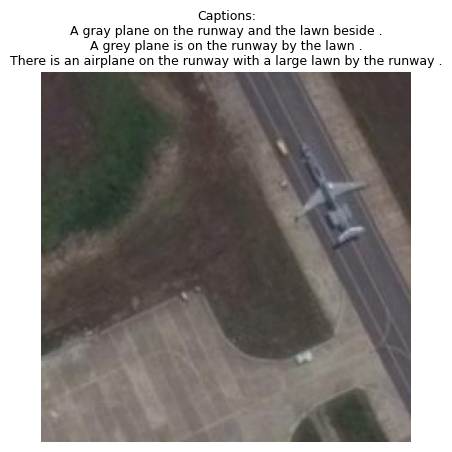

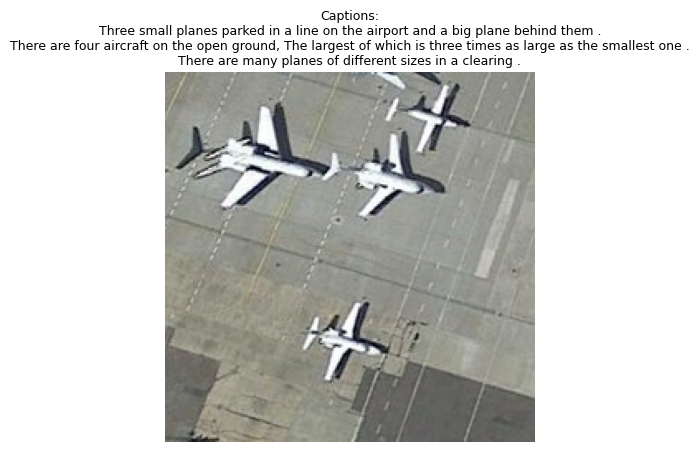

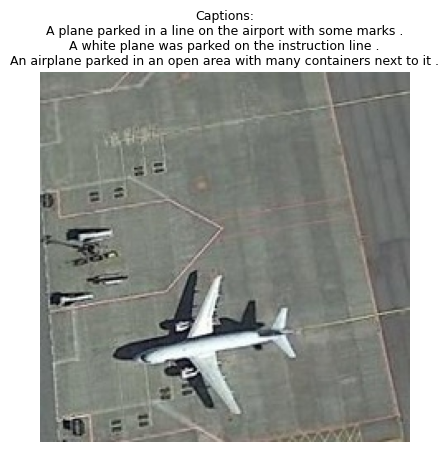

In [7]:
def show_sample(image_name):
    img_path = os.path.join(IMAGES_DIR, image_name)
    
    if not os.path.exists(img_path):
        print(f"Image {image_name} not found.")
        return
    
    img = Image.open(img_path)
    
    # Fetch all 5 captions
    row = df[df['image'] == image_name]
    if row.empty:
        print(f"No captions found for {image_name}")
        return

    captions = row[['caption_1', 'caption_2', 'caption_3', 'caption_4', 'caption_5']].values.flatten().tolist()

    plt.imshow(img)
    plt.axis('off')
    plt.title("Captions:\n" + "\n".join(captions[:3]), fontsize=9)  # Display 3 to avoid clutter
    plt.show()


# Show a few samples
sample_images = df['image'].unique()[:3]
for img_name in sample_images:
    show_sample(img_name)


### Caption lengths and noisy samples

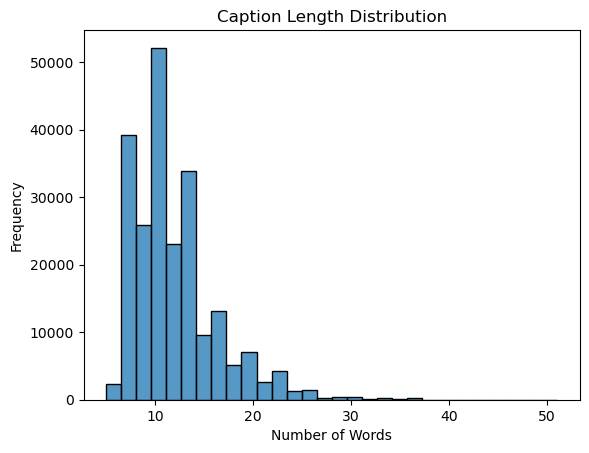

Examples of potentially noisy captions:
[]


In [9]:
# Melt the wide-format caption columns into a single long-format column
caption_cols = ['caption_1', 'caption_2', 'caption_3', 'caption_4', 'caption_5']
df_melted = df.melt(id_vars=['source', 'split', 'image'], value_vars=caption_cols,
                    var_name='caption_id', value_name='caption')

# Drop any NaNs (just in case)
df_melted = df_melted.dropna(subset=['caption'])

# Compute caption length
df_melted['caption_length'] = df_melted['caption'].astype(str).apply(lambda x: len(x.split()))

# Plot distribution of caption lengths
sns.histplot(df_melted['caption_length'], bins=30)
plt.title("Caption Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# Find short (likely low-quality) captions
short_captions = df_melted[df_melted['caption_length'] <= 3]
print("Examples of potentially noisy captions:")
print(short_captions['caption'].unique()[:10])


### image shape check

In [10]:
from tqdm import tqdm

dims = []
for img_name in tqdm(df['image'].unique()[:100]):  # just a subset for speed
    img = Image.open(os.path.join(IMAGES_DIR, img_name))
    dims.append(img.size)

dims_df = pd.DataFrame(dims, columns=['width', 'height'])
print("Image shape consistency:")
print(dims_df.describe())


100%|██████████| 100/100 [00:00<00:00, 130.79it/s]

Image shape consistency:
       width  height
count  100.0   100.0
mean   224.0   224.0
std      0.0     0.0
min    224.0   224.0
25%    224.0   224.0
50%    224.0   224.0
75%    224.0   224.0
max    224.0   224.0


### word cloud of captions

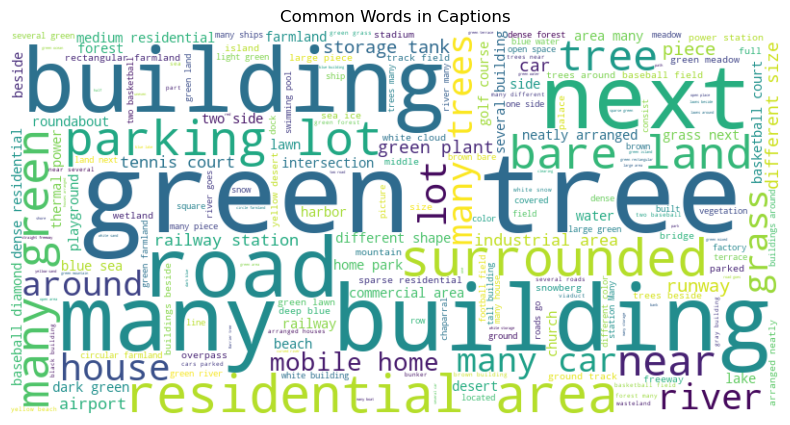

In [ ]:
from wordcloud import WordCloud

all_captions = ' '.join(df_melted['caption'].dropna().tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_captions)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Captions')
plt.savefig('caption_wordcloud.png')
plt.show()
